# Glass-Box PPO on an LLM — from scratch, every tensor visible

**Session 2 lab · companion to the PPO lecture.** No `PPOTrainer`. We build the loop by hand so each term from the slides is a printed tensor you can inspect and a dial you can turn.

### The cast (RLHF's four models, here three + a function)
| Role | In this lab |
|---|---|
| **Actor** (policy $\pi_\theta$) | GPT-2 + a value head — the thing we train |
| **Critic** (value $V_\phi$) | a linear value head on GPT-2's last hidden state |
| **Reference** $\pi_\text{ref}$ | a frozen copy of GPT-2 — the KL leash anchor |
| **Reward model** | a *trivial verifiable function* (count positive words) — no model to train |

Using a trivial reward keeps the spotlight on the **mechanics**: rollout → per-token reward shaping (terminal reward $-$ KL penalty) → GAE → importance ratio → clip → update.

### The three dials (everything from the lecture, made turnable)
- **clip $\epsilon$** — the trust region width in PPO-Clip → watch `clipfrac` and stability
- **GAE $\lambda$** — the bias/variance knob on advantages
- **KL coefficient $\beta$** — the leash to the reference. The headline experiment: sweep $\beta$ to watch **reward hacking / KL blow-up** (Goodhart, live).

> Runs on a single GPU in a few minutes with `gpt2` (124M). CPU works for tiny `batch_size`/`iters`. Swap the model name for a 0.5–1.5B model if you want — the loop is unchanged.

In [2]:
# If needed:  pip install torch transformers matplotlib
import copy, math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass, field, replace
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(0)
print("device:", device)

device: cuda


## 1 · The dials (config)

Edit this cell and re-run the training cell to feel each knob. The defaults are *starting points* — with a from-scratch loop on a trivial reward you may need to nudge `lr` / `iters` to see clean movement.

**Important, and itself a teaching point:** $\beta$ is only meaningful *relative to the reward scale*. Our reward is "number of positive words" (roughly 0–5), so a useful $\beta$ lives around 0.02–0.3. With a differently-scaled reward you'd rescale $\beta$ — exactly the scale-dependence you saw with DPO's $\beta$ as an implicit KL weight.

In [3]:
@dataclass
class PPOConfig:
    model_name: str = "gpt2"      # try "Qwen/Qwen2.5-0.5B" for a bigger actor
    prompt: str = "I watched the movie last night and"
    # --- the three dials ---
    clip_eps: float = 0.2         # PPO-Clip trust region width
    gae_lambda: float = 0.95      # GAE bias/variance knob
    kl_coef: float = 0.05         # beta: KL leash to reference  <-- the reward-hacking dial
    # --- rollout / optimization ---
    gamma: float = 1.0
    batch_size: int = 16          # completions sampled per iteration
    gen_len: int = 16             # response tokens per completion
    ppo_epochs: int = 4           # reuse each rollout this many times (off-policy-ish)
    lr: float = 2e-5
    iters: int = 60
    vf_coef: float = 0.1
    ent_coef: float = 0.0
    normalize_adv: bool = True
    temperature: float = 1.0

cfg = PPOConfig()
cfg

PPOConfig(model_name='gpt2', prompt='I watched the movie last night and', clip_eps=0.2, gae_lambda=0.95, kl_coef=0.05, gamma=1.0, batch_size=16, gen_len=16, ppo_epochs=4, lr=2e-05, iters=60, vf_coef=0.1, ent_coef=0.0, normalize_adv=True, temperature=1.0)

## 2 · Actor+critic and the frozen reference

The policy is GPT-2 with a scalar **value head** bolted onto the last hidden state, so one forward pass gives us both `logits` (actor) and `values` (critic). The reference is a frozen, grad-free copy — it never moves, and KL is measured against it.

In [4]:
class PolicyWithValueHead(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.backbone = AutoModelForCausalLM.from_pretrained(model_name)
        h = self.backbone.config.hidden_size
        self.v_head = nn.Linear(h, 1)
        nn.init.normal_(self.v_head.weight, std=1e-3); nn.init.zeros_(self.v_head.bias)
    def forward(self, ids, attn=None):
        out = self.backbone(input_ids=ids, attention_mask=attn, output_hidden_states=True)
        values = self.v_head(out.hidden_states[-1]).squeeze(-1)   # (B, S)
        return out.logits, values                                # (B,S,V), (B,S)

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
tokenizer.pad_token = tokenizer.eos_token

policy = PolicyWithValueHead(cfg.model_name).to(device)
ref = AutoModelForCausalLM.from_pretrained(cfg.model_name).to(device).eval()
for p in ref.parameters(): p.requires_grad_(False)
print("loaded", cfg.model_name, "| params:", sum(p.numel() for p in policy.parameters())/1e6, "M")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

loaded gpt2 | params: 124.440577 M


## 3 · The trivial, verifiable reward

A scalar per completion. Swap it freely — that's the only "reward model" here. Default rewards positivity (continuity with the sentiment PPO demo you'll show next). Over-optimizing it produces visible word-salad — which is the point.

In [5]:
POSITIVE = {"good","great","love","loved","amazing","wonderful","best","fantastic",
            "awesome","beautiful","brilliant","perfect","excellent","happy","enjoyed","delightful"}

def reward_fn(texts):
    # Trivial verifiable reward: count of positive words in the response text
    out = []
    for t in texts:
        words = t.lower().replace(".", " ").replace(",", " ").split()
        out.append(float(sum(w in POSITIVE for w in words)))
    return torch.tensor(out, device=device)

# Alternatives to try (uncomment one):
def reward_fn(texts): return torch.tensor([float(t.count("!")) for t in texts], device=device)
# def reward_fn(texts): return torch.tensor([float(sum(c.isdigit() for c in t)) for t in texts], device=device)

## 4 · The alignment helpers (where everyone gets an off-by-one)

For a sequence `[prompt(0..L-1) | response(L..L+T-1)]`:
- the logits that **predict** response token at absolute position `L+t` sit at position `L+t-1`;
- the value of the **state** from which we emit that token is the hidden value at position `L+t-1`.

So both the response log-probs and the response values come from the slice `[L-1 : L-1+T]`. Getting this slice right is 90% of a correct from-scratch PPO.

In [6]:
def logps_of(logits, ids):
    # log-prob assigned to the realized next tokens (logits already aligned to predict ids)
    return torch.gather(F.log_softmax(logits, -1), 2, ids.unsqueeze(-1)).squeeze(-1)

def entropy_of(logits):
    p = F.softmax(logits, -1); lp = F.log_softmax(logits, -1)
    return -(p * lp).sum(-1)

def aligned_logps_values(model, seq, L, T, is_policy):
    # is_policy=True -> model returns (logits, values); else a plain LM returning .logits
    if is_policy:
        logits, values = model(seq)
    else:
        logits, values = model(seq).logits, None
    pred = logits[:, L-1:L-1+T, :]          # predicts the T response tokens
    resp = seq[:, L:L+T]
    lp = logps_of(pred, resp)               # (B,T)
    ent = entropy_of(pred)                  # (B,T)
    V = values[:, L-1:L-1+T] if is_policy else None
    return lp, V, ent

## 5 · Rollout — manual sampling (the glass box)

We sample `B` continuations from the **same** prompt (so all sequences share length → zero padding, and the baseline $V(s_0)$ is comparable across the batch). We sample by hand rather than `.generate()` so the rollout is fully visible.

In [7]:
@torch.no_grad()
def rollout(cfg):
    L = len(tokenizer(cfg.prompt)["input_ids"])
    prompt_ids = torch.tensor(tokenizer(cfg.prompt)["input_ids"], device=device)
    seq = prompt_ids[None].repeat(cfg.batch_size, 1)
    for _ in range(cfg.gen_len):
        logits, _ = policy(seq)
        probs = F.softmax(logits[:, -1] / cfg.temperature, -1)
        nxt = torch.multinomial(probs, 1)
        seq = torch.cat([seq, nxt], 1)
    texts = tokenizer.batch_decode(seq[:, L:], skip_special_tokens=True)
    return seq, L, cfg.gen_len, texts

## 6 · Reward shaping + GAE

Per-token reward is the **KL penalty** at every step plus the **terminal reward** on the last token:
$$r_t = -\beta\,\big(\log\pi_\theta(a_t)-\log\pi_\text{ref}(a_t)\big),\qquad r_{T-1}\mathrel{+}= R(\text{seq}).$$
Then GAE turns per-token rewards + critic values into advantages:
$$\delta_t = r_t + \gamma V_{t+1} - V_t,\qquad A_t = \delta_t + \gamma\lambda A_{t+1},\qquad \text{return}_t = A_t + V_t.$$

In [8]:
def build_rewards(R, kl_tok, beta):
    rew = -beta * kl_tok                       # (B,T) per-token KL penalty
    rew[:, -1] = rew[:, -1] + R                # terminal scalar reward
    return rew

def compute_gae(rewards, values, gamma, lam):
    B, T = rewards.shape
    adv = torch.zeros_like(rewards); last = torch.zeros(B, device=rewards.device)
    for t in reversed(range(T)):
        next_v = values[:, t+1] if t+1 < T else torch.zeros(B, device=rewards.device)
        delta = rewards[:, t] + gamma * next_v - values[:, t]
        last = delta + gamma * lam * last
        adv[:, t] = last
    return adv, adv + values

## 7 · 🔍 The single-step glass box — *the centerpiece of this lab*

One rollout, then we print, for the first completion, every quantity from the lecture next to the **decoded token**: old log-prob, reference log-prob, KL, critic value, advantage, return. Then we take **one** update step and print the **importance ratio** and the **clipped vs unclipped surrogate** side by side.

In [9]:
seq, L, T, texts = rollout(cfg)
with torch.no_grad():
    old_lp, old_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
    ref_lp, _, _     = aligned_logps_values(ref,    seq, L, T, is_policy=False)
kl_tok = old_lp - ref_lp
R = reward_fn(texts)
rew = build_rewards(R, kl_tok, cfg.kl_coef)
adv, ret = compute_gae(rew, old_V, cfg.gamma, cfg.gae_lambda)

print("PROMPT:", repr(cfg.prompt))
print("SAMPLE COMPLETION [0]:", repr(texts[0]), "| reward R =", R[0].item(), "\n")
resp_tokens = seq[0, L:L+T]
hdr = f"{'token':>12}{'old_lp':>9}{'ref_lp':>9}{'kl':>8}{'V':>8}{'adv':>8}{'ret':>8}"
print(hdr); print("-"*len(hdr))
for t in range(min(T, 8)):
    tok = repr(tokenizer.decode(resp_tokens[t]))
    print(f"{tok:>12}{old_lp[0,t]:>9.3f}{ref_lp[0,t]:>9.3f}{kl_tok[0,t]:>8.3f}"
          f"{old_V[0,t]:>8.3f}{adv[0,t]:>8.3f}{ret[0,t]:>8.3f}")

PROMPT: 'I watched the movie last night and'
SAMPLE COMPLETION [0]: ' thought it was outstanding. B together from a text writer Bill, we discussed it' | reward R = 0.0 

       token   old_lp   ref_lp      kl       V     adv     ret
--------------------------------------------------------------
  ' thought'   -3.148   -3.148   0.000   0.296  -0.162   0.134
       ' it'   -1.624   -1.624   0.000   0.233  -0.104   0.129
      ' was'   -0.292   -0.292   0.000   0.235  -0.112   0.124
' outstanding'   -9.077   -9.077   0.000   0.245  -0.128   0.117
         '.'   -0.582   -0.582   0.000   0.177  -0.063   0.114
        ' B'   -8.086   -8.086   0.000   0.296  -0.192   0.104
 ' together'  -11.242  -11.242   0.000   0.234  -0.137   0.098
     ' from'   -6.494   -6.494   0.000   0.205  -0.113   0.092


In [10]:
# --- one update step, printing the ratio and the clipped surrogate ---
adv_n = (adv - adv.mean()) / (adv.std() + 1e-8) if cfg.normalize_adv else adv
new_lp, new_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)  # == old on step 1
ratio = torch.exp(new_lp - old_lp)
unclipped = ratio * adv_n
clipped = torch.clamp(ratio, 1-cfg.clip_eps, 1+cfg.clip_eps) * adv_n
surrogate = torch.min(unclipped, clipped)

print("On the FIRST epoch new==old, so ratio==1 everywhere (sanity check):")
print(f"{'token':>12}{'ratio':>9}{'adv_norm':>10}{'unclip':>9}{'clip':>9}{'used':>9}")
for t in range(min(T, 8)):
    tok = repr(tokenizer.decode(seq[0, L+t]))
    print(f"{tok:>12}{ratio[0,t]:>9.3f}{adv_n[0,t]:>10.3f}{unclipped[0,t]:>9.3f}"
          f"{clipped[0,t]:>9.3f}{surrogate[0,t]:>9.3f}")
print("\nAfter several PPO epochs the ratio drifts from 1 and the clip starts biting —")
print("that's what `clipfrac` in the training curves measures.")

On the FIRST epoch new==old, so ratio==1 everywhere (sanity check):
       token    ratio  adv_norm   unclip     clip     used
  ' thought'    1.000    -0.090   -0.090   -0.090   -0.090
       ' it'    1.000     0.230    0.230    0.230    0.230
      ' was'    1.000     0.187    0.187    0.187    0.187
' outstanding'    1.000     0.096    0.096    0.096    0.096
         '.'    1.000     0.454    0.454    0.454    0.454
        ' B'    1.000    -0.256   -0.256   -0.256   -0.256
 ' together'    1.000     0.048    0.048    0.048    0.048
     ' from'    1.000     0.181    0.181    0.181    0.181

After several PPO epochs the ratio drifts from 1 and the clip starts biting —
that's what `clipfrac` in the training curves measures.


## 8 · The PPO update and the training loop

For each rollout we run `ppo_epochs` passes (data reuse — the mild off-policy-ness you discussed): recompute new log-probs/values, form the ratio against the **fixed** old log-probs, clip, add a value-function loss and optional entropy bonus, step.

In [12]:
def ppo_update(seq, L, T, old_lp, old_V, adv, ret, cfg, opt):
    adv_n = (adv - adv.mean())/(adv.std()+1e-8) if cfg.normalize_adv else adv
    stats = {"clipfrac": [], "pg": [], "vf": [], "ent": []}
    for _ in range(cfg.ppo_epochs):
        new_lp, new_V, ent = aligned_logps_values(policy, seq, L, T, is_policy=True)
        ratio = torch.exp(new_lp - old_lp)
        pg = -torch.min(ratio*adv_n,
                        torch.clamp(ratio, 1-cfg.clip_eps, 1+cfg.clip_eps)*adv_n).mean()
        vf = 0.5 * (new_V - ret).pow(2).mean()
        loss = pg + cfg.vf_coef*vf - cfg.ent_coef*ent.mean()
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
        stats["clipfrac"].append(((ratio-1).abs() > cfg.clip_eps).float().mean().item())
        stats["pg"].append(pg.item()); stats["vf"].append(vf.item()); stats["ent"].append(ent.mean().item())
    return {k: sum(v)/len(v) for k,v in stats.items()}

def train(cfg, log_every=10):
    opt = torch.optim.Adam(policy.parameters(), lr=cfg.lr)
    H = {"reward": [], "kl": [], "clipfrac": [], "entropy": []}
    for it in range(cfg.iters):
        seq, L, T, texts = rollout(cfg)
        with torch.no_grad():
            old_lp, old_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
            ref_lp, _, _     = aligned_logps_values(ref,    seq, L, T, is_policy=False)
        kl_tok = old_lp - ref_lp
        R = reward_fn(texts)
        rew = build_rewards(R, kl_tok, cfg.kl_coef)
        adv, ret = compute_gae(rew, old_V, cfg.gamma, cfg.gae_lambda)
        s = ppo_update(seq, L, T, old_lp, old_V, adv, ret, cfg, opt)
        H["reward"].append(R.mean().item()); H["kl"].append(kl_tok.sum(-1).mean().item())
        H["clipfrac"].append(s["clipfrac"]); H["entropy"].append(s["ent"])
        if it % log_every == 0:
            print(f"it{it:3d}  reward {R.mean():6.3f}  KL/seq {kl_tok.sum(-1).mean():7.3f}"
                  f"  clipfrac {s['clipfrac']:.3f}  ent {s['ent']:.3f}")
    return H

## 9 · Train (with the KL leash on)

Reward should climb while KL stays bounded. If reward is flat, raise `lr` or `iters`; if KL explodes, raise `kl_coef`.

In [13]:
policy_fresh_state = copy.deepcopy(policy.state_dict())  # save for before/after + sweeps
H = train(cfg)

it  0  reward  0.000  KL/seq   0.000  clipfrac 0.360  ent 3.553
it 10  reward  0.312  KL/seq   0.852  clipfrac 0.077  ent 4.015
it 20  reward  0.000  KL/seq   1.630  clipfrac 0.083  ent 3.601
it 30  reward  0.125  KL/seq   1.484  clipfrac 0.077  ent 3.621
it 40  reward  2.250  KL/seq  11.780  clipfrac 0.089  ent 2.601
it 50  reward  3.688  KL/seq  23.553  clipfrac 0.107  ent 1.747


## 10 · The training curves

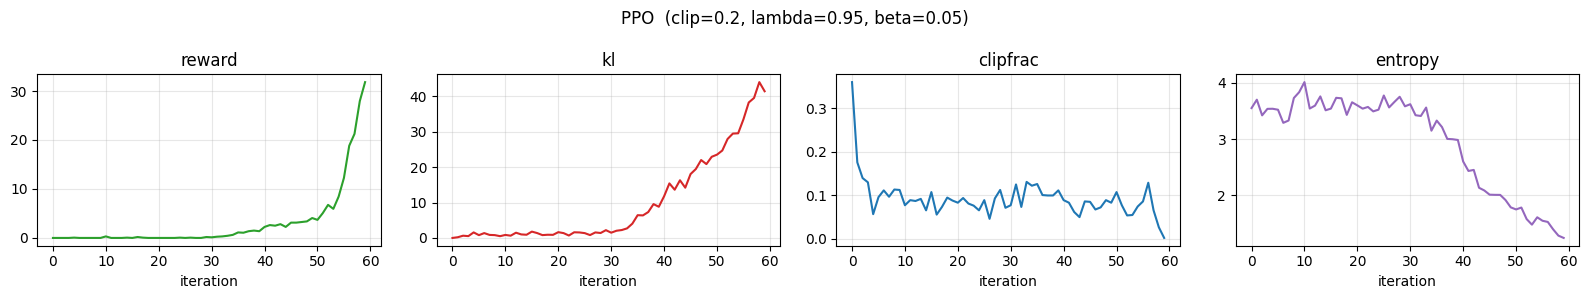

In [14]:
def plot_hist(H, title=""):
    fig, ax = plt.subplots(1, 4, figsize=(16, 3))
    for a,(k,c) in zip(ax, [("reward","tab:green"),("kl","tab:red"),
                            ("clipfrac","tab:blue"),("entropy","tab:purple")]):
        a.plot(H[k], color=c); a.set_title(k); a.set_xlabel("iteration"); a.grid(alpha=.3)
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_hist(H, f"PPO  (clip={cfg.clip_eps}, lambda={cfg.gae_lambda}, beta={cfg.kl_coef})")

## 11 · Before vs after — did behavior actually change?

In [15]:
@torch.no_grad()
def sample_some(n=4):
    saved = copy.deepcopy(policy.state_dict()); out = {}
    for label, state in [("BEFORE", policy_fresh_state), ("AFTER", saved)]:
        policy.load_state_dict(state)
        c = replace(cfg, batch_size=n)
        _, _, _, texts = rollout(c)
        out[label] = (texts, reward_fn(texts))
    policy.load_state_dict(saved)
    return out

for label,(texts,R) in sample_some().items():
    print(f"\n=== {label}  (mean reward {R.mean():.2f}) ===")
    for t,r in zip(texts, R): print(f"  [{r:.0f}] {cfg.prompt}{t}")


=== BEFORE  (mean reward 0.00) ===
  [0] I watched the movie last night and it wasn't just a lather. I had a piece of sound out of
  [0] I watched the movie last night and wondered if now was the time to get it done because Rin could see it thinking
  [0] I watched the movie last night and there was this big-time bunny-like time shot," Kenney tells me
  [0] I watched the movie last night and hesitated a moment before responding.

Reading Smarttop Cafe's Stand Still (

=== AFTER  (mean reward 32.25) ===
  [30] I watched the movie last night and saw so dope!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  [39] I watched the movie last night and loved!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  [30] I watched the movie last night and loved it!! It amazing!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  [30] I watched the movie last night and loved!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## 12 · 🎯 Headline experiment: sweep $\beta$ → reward hacking / KL blow-up

Re-run training from the same fresh weights for several KL coefficients and overlay the curves. The story you'll see:

- **$\beta = 0$** (no leash): reward keeps climbing, **KL runs away**, completions degenerate into positive-word salad — *Goodhart's law*, the model games the reward.
- **moderate $\beta$**: reward improves while KL stays bounded — the regime you actually want.
- **large $\beta$**: the leash dominates, the policy barely moves, reward stays flat.

This is *why* RLHF keeps a reference model and a KL penalty — exactly the term in our PPO loss slide.


--- beta = 0.0 ---
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.412  ent 3.724

--- beta = 0.05 ---
it  0  reward  0.062  KL/seq   0.000  clipfrac 0.293  ent 3.502

--- beta = 0.2 ---
it  0  reward  0.062  KL/seq   0.000  clipfrac 0.357  ent 3.589

--- beta = 1.0 ---
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.399  ent 3.752


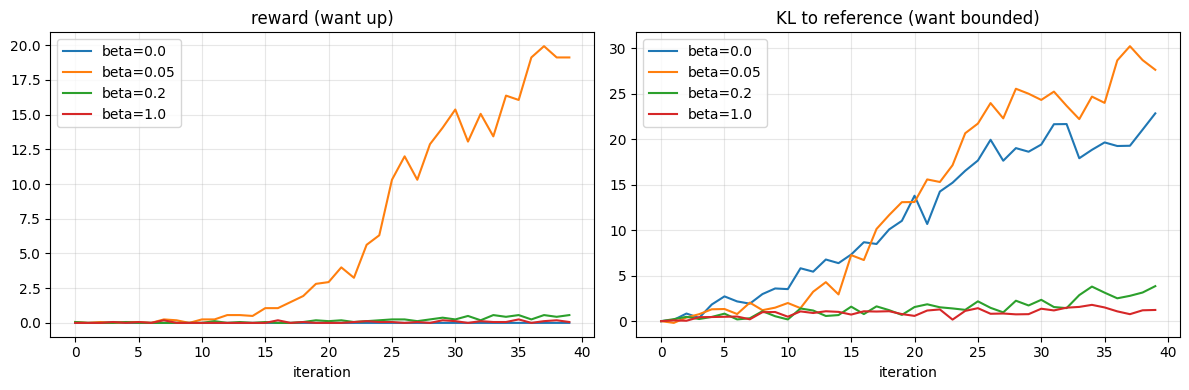

In [16]:
def run_sweep(betas, iters=40):
    runs = {}
    policy_states = {}
    for b in betas:
        policy.load_state_dict(copy.deepcopy(policy_fresh_state))
        c = replace(cfg, kl_coef=b, iters=iters)
        print(f"\n--- beta = {b} ---")
        runs[b] = train(c, log_every=iters)  # only final line
        policy_states[b] = copy.deepcopy(policy.state_dict())
    return runs, policy_states

sweep, sweep_states = run_sweep([0.0, 0.05, 0.2, 1.0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for b, H in sweep.items():
    ax[0].plot(H["reward"], label=f"beta={b}")
    ax[1].plot(H["kl"], label=f"beta={b}")
ax[0].set_title("reward (want up)"); ax[1].set_title("KL to reference (want bounded)")
for a in ax: a.set_xlabel("iteration"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [15]:
# Per-token prediction breakdown for each beta after the sweep (mirrors cell 16)
saved_policy = copy.deepcopy(policy.state_dict())

for b, state in sweep_states.items():
    policy.load_state_dict(state)
    seq, L, T, texts = rollout(replace(cfg, batch_size=1))
    with torch.no_grad():
        old_lp, old_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
        ref_lp, _, _     = aligned_logps_values(ref,    seq, L, T, is_policy=False)
    kl_tok = old_lp - ref_lp
    R = reward_fn(texts)
    rew = build_rewards(R, kl_tok, b)
    adv, ret = compute_gae(rew, old_V, cfg.gamma, cfg.gae_lambda)

    print(f"\n=== beta = {b}  |  reward R = {R[0].item():.2f} ===")
    print("SAMPLE COMPLETION:", repr(cfg.prompt + texts[0]))
    resp_tokens = seq[0, L:L+T]
    hdr = f"{'token':>12}{'old_lp':>9}{'ref_lp':>9}{'kl':>8}{'V':>8}{'adv':>8}{'ret':>8}"
    print(hdr); print("-" * len(hdr))
    for t in range(min(T, 8)):
        tok = repr(tokenizer.decode(resp_tokens[t]))
        print(f"{tok:>12}{old_lp[0,t]:>9.3f}{ref_lp[0,t]:>9.3f}{kl_tok[0,t]:>8.3f}"
              f"{old_V[0,t]:>8.3f}{adv[0,t]:>8.3f}{ret[0,t]:>8.3f}")

policy.load_state_dict(saved_policy)


=== beta = 0.0  |  reward R = 14.00 ===
SAMPLE COMPLETION: 'I watched the movie last night and loved loved love loved loved loved loved. I love love love love love love love'
       token   old_lp   ref_lp      kl       V     adv     ret
--------------------------------------------------------------
    ' loved'   -0.597   -6.310   5.712   4.520   4.712   9.232
    ' loved'   -1.625  -13.770  12.145   4.979   4.477   9.456
     ' love'   -0.219   -4.880   4.661   5.216   4.463   9.679
    ' loved'   -0.867   -6.380   5.514   5.208   4.706   9.915
    ' loved'   -0.146   -3.150   3.004   5.173   4.991  10.164
    ' loved'   -0.355   -1.498   1.143   5.215   5.210  10.425
    ' loved'   -0.790   -1.095   0.305   5.241   5.456  10.698
         '.'   -2.927   -2.352  -0.574   5.256   5.728  10.984

=== beta = 0.05  |  reward R = 15.00 ===
SAMPLE COMPLETION: 'I watched the movie last night and it great great great great great great great great great great great great great great great'
   

<All keys matched successfully>

## 13 · (Optional) live sliders

If `ipywidgets` renders in your environment (Colab/Jupyter), this gives tap-to-change dials. If it doesn't render, just edit the **config cell** and re-run training, or use the sweep above — same lesson, no widget dependency.

In [ ]:
try:
    import ipywidgets as W
    from IPython.display import display
    def run(clip_eps, gae_lambda, kl_coef, lr_exp, iters):
        policy.load_state_dict(copy.deepcopy(policy_fresh_state))
        c = replace(cfg, clip_eps=clip_eps, gae_lambda=gae_lambda,
                         kl_coef=kl_coef, lr=10**lr_exp, iters=iters)
        plot_hist(train(c, log_every=iters), f"clip={clip_eps} lam={gae_lambda} beta={kl_coef}")
        _, _, _, texts = rollout(replace(c, batch_size=4))
        R = reward_fn(texts)
        print(f"\nSample completions after training  (mean reward {R.mean():.2f}):")
        for t, r in zip(texts, R):
            print(f"  [{r:.0f}] {cfg.prompt}{t}")
    W.interact_manual(run,
        clip_eps=W.FloatSlider(value=CLIP_EPS, min=0.05, max=0.6, step=0.05),
        gae_lambda=W.FloatSlider(value=GAE_LAMBDA, min=0.0, max=1.0, step=0.05),
        kl_coef=W.FloatSlider(value=KL_COEF, min=0.0, max=1.0, step=0.05),
        lr_exp=W.FloatSlider(value=LR_EXP, min=-6, max=-4, step=0.1, description="log10(lr)"),
        iters=W.IntSlider(value=ITERS, min=10, max=120, step=10))
except Exception as e:
    print("ipywidgets not available — use the config cell + sweep instead.", e)

interactive(children=(FloatSlider(value=0.2, description='clip_eps', max=0.6, min=0.05, step=0.05), FloatSlide…

## 14 · Student exercises (predict → turn the dial → verify)

1. **Clip $\epsilon$.** Set `clip_eps` to 0.05 and to 0.6. Predict the effect on `clipfrac` and on stability *before* running. Which gives faster but riskier learning?
2. **GAE $\lambda$.** Compare $\lambda=0$ (high-bias, one-step TD) vs $\lambda=1$ (high-variance, Monte-Carlo). Watch the noise in the reward curve.
3. **$\beta$ vs reward scale.** Switch `reward_fn` to the `!`-counting version (much larger magnitude). What happens to the good $\beta$ range? (Lesson: the KL coefficient is *scale-dependent* — same point as DPO's $\beta$.)
4. **PPO epochs.** Push `ppo_epochs` to 8. Why does `clipfrac` rise? When does data reuse start to hurt?
5. **Kill the critic.** Replace advantages with `returns - returns.mean()` (no value head). What did GAE buy you?

### Dial → effect cheat-sheet
| Dial | Too low | Too high |
|---|---|---|
| clip $\epsilon$ | over-cautious, slow | big risky steps, instability |
| GAE $\lambda$ | biased advantages | noisy, high-variance updates |
| KL $\beta$ | **reward hacking, KL blow-up** | policy frozen, no learning |

In [ ]:
# Missing dial defaults (match the interactive sliders); only clip_eps varies here
CLIP_EPS=0.2
GAE_LAMBDA = 0.95
KL_COEF = 0.05
LR_EXP = -4.7
ITERS = 40


##### 1: Clip $\epsilon$
I predict 0.05 will have higher stability and higher clipfrac (more clipping events) and 0.6 will have lower ones. \
$\epsilon$ is what determines our clipping range, so a lower $\epsilon$ causes a tighter range and higher ratio of clipping

it  0  reward  0.062  KL/seq   0.000  clipfrac 0.546  ent 3.586


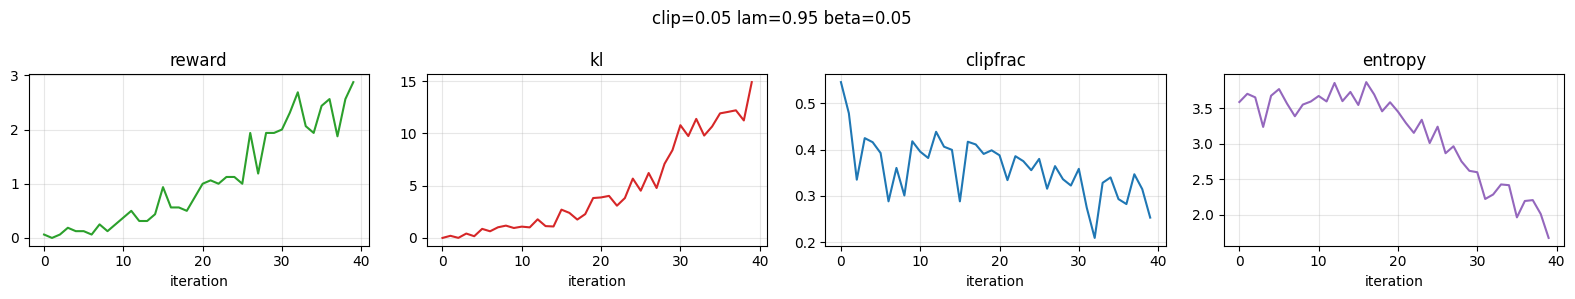


Sample completions after training  (mean reward 3.50):
  [4] I watched the movie last night and I loved it. It's great. I love it. I love it,
  [4] I watched the movie last night and loved it. I love it. I love it. I love it. I
  [4] I watched the movie last night and loved it. It's great but I love it. And I love it.
  [2] I watched the movie last night and actually enjoyed it 100% - it's a phenomenal movie. It's amazing -
it  0  reward  0.125  KL/seq   0.000  clipfrac 0.075  ent 3.696


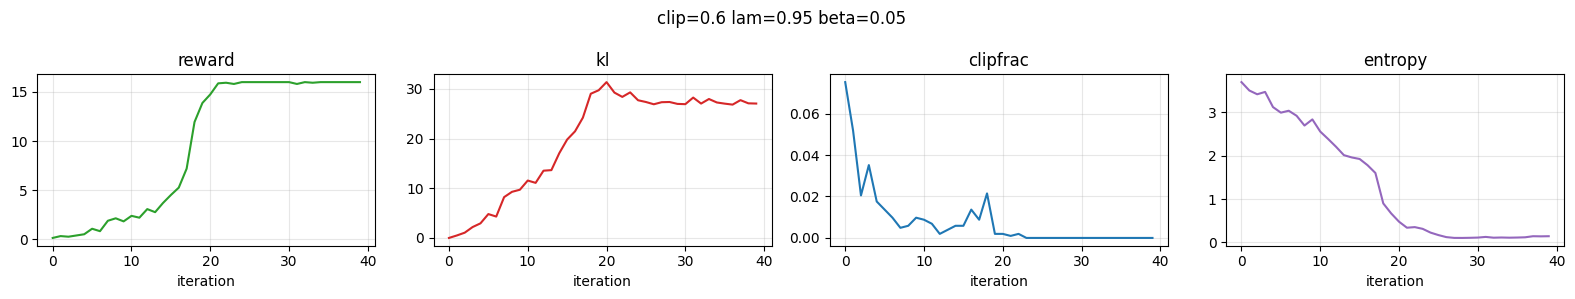


Sample completions after training  (mean reward 16.00):
  [16] I watched the movie last night and great great great great great great great great great great great great great great great great
  [16] I watched the movie last night and great great great great great great great great great great great great great great great great
  [16] I watched the movie last night and fantastic great great great great great great great great great great great great great great great
  [16] I watched the movie last night and great great great great great great great great great great great great great great great great


In [43]:
run(clip_eps=0.05, gae_lambda=GAE_LAMBDA, kl_coef=KL_COEF, lr_exp=LR_EXP, iters=ITERS)
run(clip_eps=0.6,  gae_lambda=GAE_LAMBDA, kl_coef=KL_COEF, lr_exp=LR_EXP, iters=ITERS)


results match our predictions, clipfrac remained higher and reward climbed much more slowly

##### 2: GAE $\lambda$


it  0  reward  0.312  KL/seq   0.000  clipfrac 0.372  ent 3.584


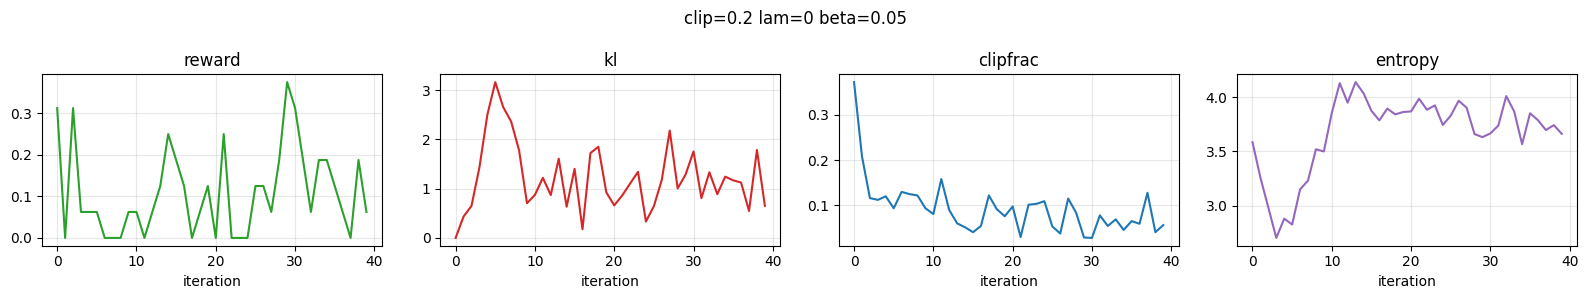


Sample completions after training  (mean reward 0.25):
  [0] I watched the movie last night and I remember rousing my kids because the movie was written by screaming people erud
  [1] I watched the movie last night and enjoyed it very much. I liked the visuals. I was quick to briefly correct
  [0] I watched the movie last night and that's when it dawned on me, I wasn't going to go following
  [0] I watched the movie last night and I'm wiped out. It was almost like I just sang Hyppub's
it  0  reward  0.250  KL/seq   0.000  clipfrac 0.417  ent 3.542


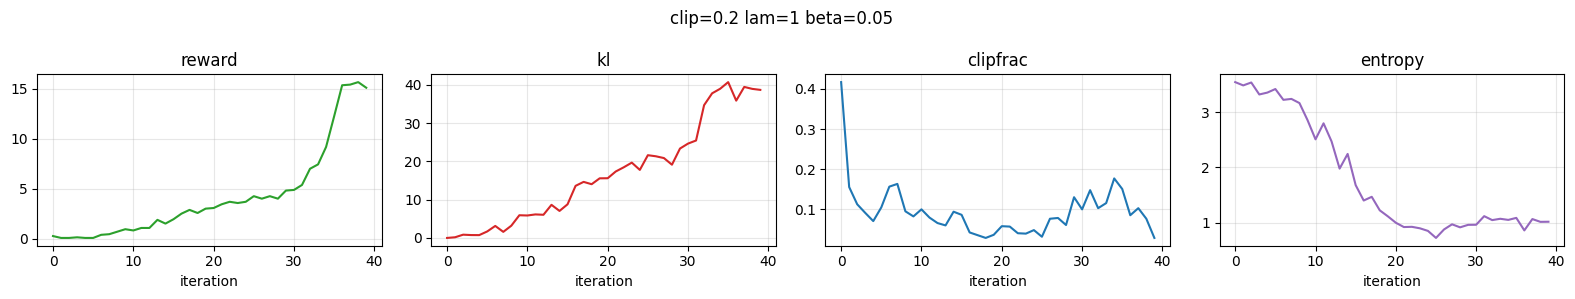


Sample completions after training  (mean reward 15.25):
  [14] I watched the movie last night and it really great good good good great great great great good great great great great great
  [15] I watched the movie last night and loved it good good good good good great good great good great great great great great
  [16] I watched the movie last night and loved great great love great good great love great great love great good great great love
  [16] I watched the movie last night and love love great love great great love great love great love great love good love great


In [ ]:
run(clip_eps=CLIP_EPS, gae_lambda=0, kl_coef=KL_COEF, lr_exp=LR_EXP, iters=ITERS)
run(clip_eps=CLIP_EPS,  gae_lambda=1, kl_coef=KL_COEF, lr_exp=LR_EXP, iters=ITERS)


We see that for $\lambda=1$ (Monte Carlo) the **reward climbs smoothly and then plateaus high** (~16): full returns put the terminal positivity score on early tokens, so the policy quickly discovers the hack (`great love great...`), entropy collapses, and KL jumps and stays large.

For $\lambda=0$ (one-step TD) the **reward curve stays low and jittery** and never locks onto that hack: advantages only trust $V_{t+1}-V_t$, and with a terminal-only $R$ a weak critic fails to credit early tokens. Entropy stays high, KL stays small, and samples remain diverse / mostly fluent - learning signal is weak, not "stable hacking."

##### 3. **$\beta$ vs reward scale.** 

it  0  reward  0.062  KL/seq   0.000  clipfrac 0.322  ent 3.408


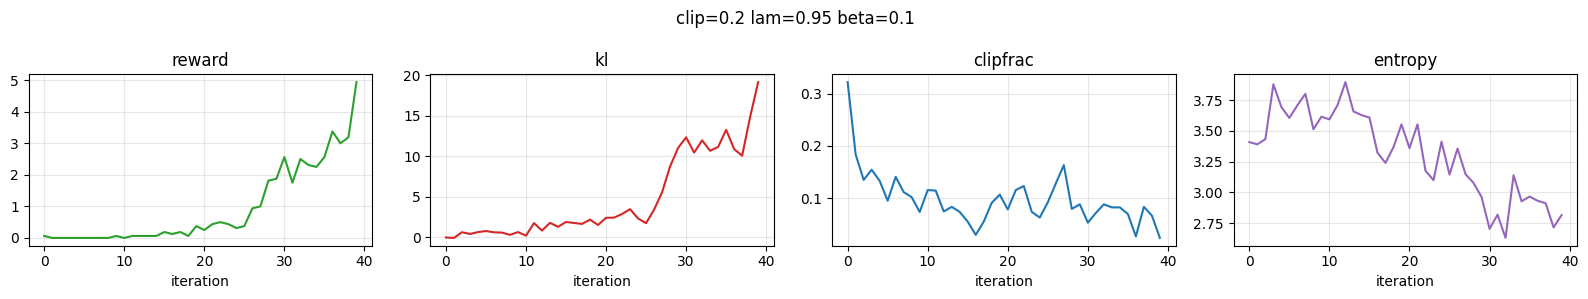


Sample completions after training  (mean reward 3.75):
  [3] I watched the movie last night and deliciously! It was amazing! I heard the awesome! It actually… It
  [3] I watched the movie last night and it was amazing! It was amazing! It was amazing! It really is incredible
  [6] I watched the movie last night and I assumed it was great!!), "this is all for!?!?!?!
  [3] I watched the movie last night and started into some rhymes verse! It was amazing! I was blown away!


In [20]:
# first, baseline run, original reward, changing kl_coef to be a bit higher so to not saturate 
STABLE_KL_COEF = 0.1
run(clip_eps=CLIP_EPS,  gae_lambda=GAE_LAMBDA, kl_coef=STABLE_KL_COEF, lr_exp=LR_EXP, iters=ITERS)


it  0  reward  0.000  KL/seq   0.000  clipfrac 0.374  ent 3.700


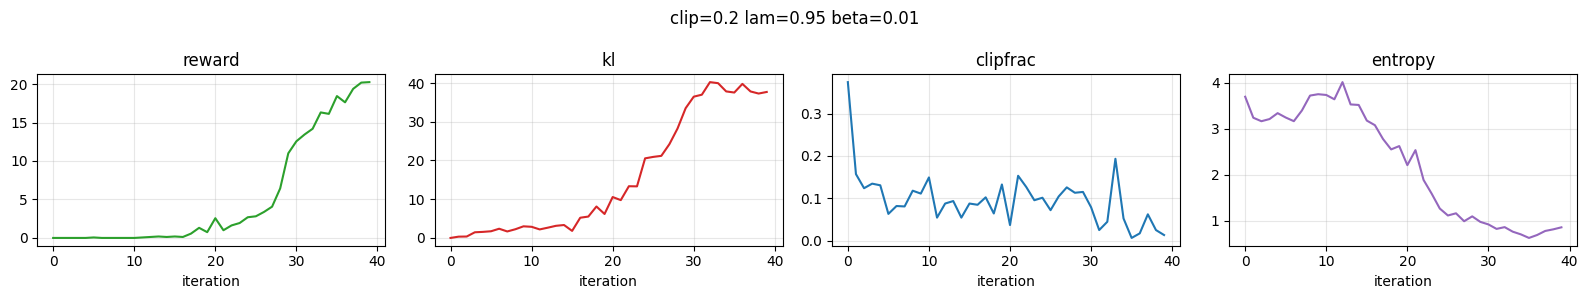


Sample completions after training  (mean reward 22.75):
  [24] I watched the movie last night and I was like <!!!!!!!!!!!!!!!!!!!!!!!!
  [26] I watched the movie last night and I was like!!!!!!!!!!!!!!!!!!!!!!!!!!
  [21] I watched the movie last night and I'm like,!!!!!!!!!!!R!!!!!!!!!!
  [20] I watched the movie last night and I was like,!!!!!!!!!!!!!!!!!!!!
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.385  ent 3.672


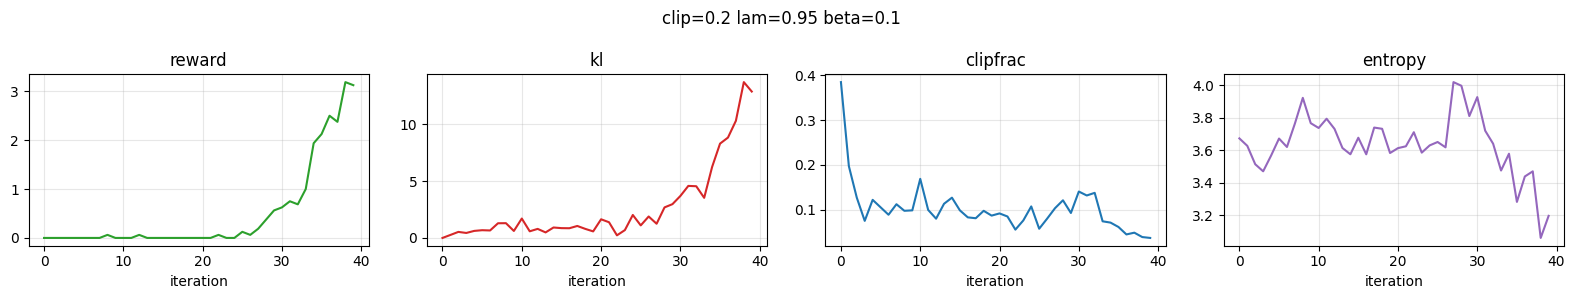


Sample completions after training  (mean reward 6.00):
  [3] I watched the movie last night and I love it! I'd love any photos of the scenes! Hehe!
  [16] I watched the movie last night and Future Man died! No!!!! No!!!!! No!!!!! What!
  [4] I watched the movie last night and I was like - Is it this?!!?! Ah fuck! What is this
  [1] I watched the movie last night and when I saw it I was like, man! What do I do? 11
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.377  ent 3.577


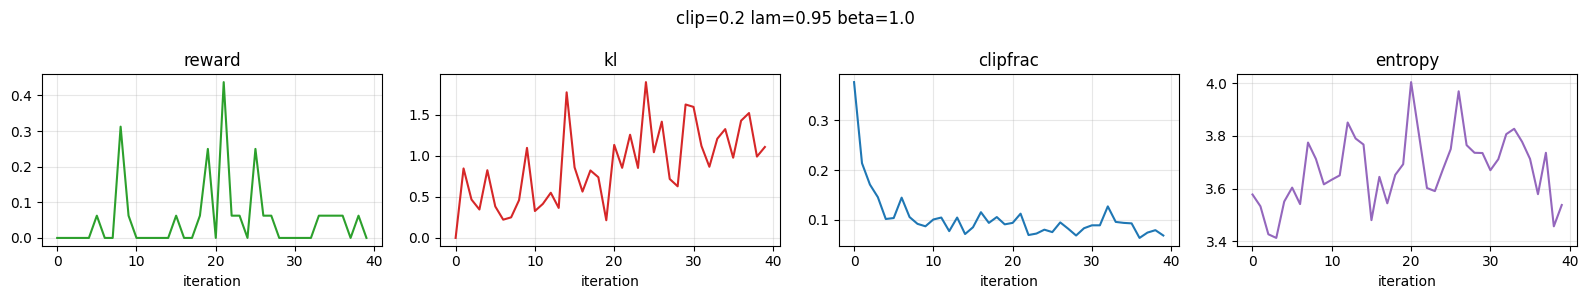


Sample completions after training  (mean reward 0.00):
  [0] I watched the movie last night and was told to lick the grave. I feel like poodle walk."


  [0] I watched the movie last night and most likely didn't hear it.


Cf. Sifa In the
  [0] I watched the movie last night and talked to my agent very closely about the first day, thinking," Wright said.
  [0] I watched the movie last night and I was like, 'Yeah.'"

What made you first feel a little


In [58]:
run(clip_eps=CLIP_EPS, gae_lambda=GAE_LAMBDA, kl_coef=STABLE_KL_COEF/10, lr_exp=LR_EXP, iters=ITERS)
run(clip_eps=CLIP_EPS,  gae_lambda=GAE_LAMBDA, kl_coef=STABLE_KL_COEF, lr_exp=LR_EXP, iters=ITERS)
run(clip_eps=CLIP_EPS,  gae_lambda=GAE_LAMBDA, kl_coef=STABLE_KL_COEF*10, lr_exp=LR_EXP, iters=ITERS)


We see that for the "!" reward function, the same kl_coef affects learning differently. \
With the positivty reward, R climbs quicker, ! only starts climbing after iteration 30. \
what's mitigating !: the baseline policy is more likely to emit phrases in the positivity reward pool than a "!" token, and a series of "!" are less likely. \
So more exploration is required to get any reward under the ! definition. if we set iter to be higher, we probably will see a harsher difference between the 2 for the same kl_coef.

with larger possible R, the same kl_coef is a weaker leash, so you need a higher kl_coef to push rewards up while keeping the KL penalty relevant. 

#### 4. **PPO epochs.**

it  0  reward  0.000  KL/seq   0.000  clipfrac 0.381  ent 3.613


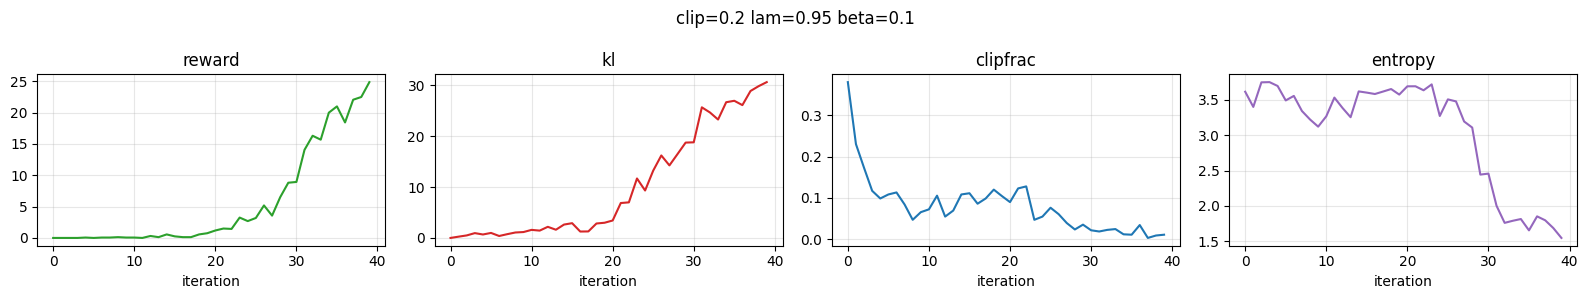


Sample completions after training  (mean reward 19.75):
  [14] I watched the movie last night and couldn't even believe it!?!?!?!?!!?!?!!!!!!!
  [11] I watched the movie last night and it went! Because this is my favorite EVER!!!!!!'?!?!?!?!
  [25] I watched the movie last night and it is stunning!!!!!!!!!!!!!!!?!!!!!!!!!!
  [29] I watched the movie last night and it is special!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
it  0  reward  0.062  KL/seq   0.000  clipfrac 0.561  ent 3.759


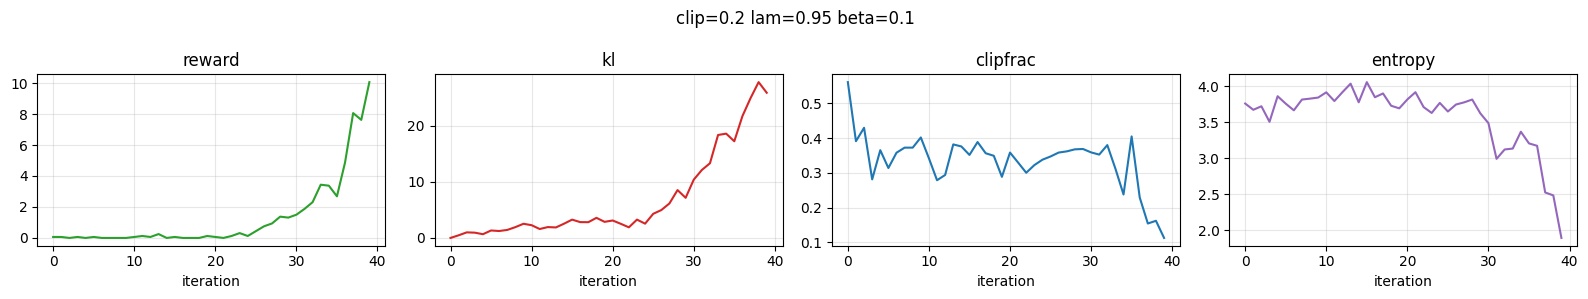


Sample completions after training  (mean reward 14.25):
  [13] I watched the movie last night and blasted out Vent!?!?!?!?!?!!!!!!!!
  [16] I watched the movie last night and gasped!!?!?!?!?!?!?!?!?!?!?!?!?!?!?!
  [16] I watched the movie last night and rejoiced at how good the movie was!!!!!!!!!!!!!!!!
  [12] I watched the movie last night and gasped clearly!  WHAT?!?!?!?!?!?!?!?!?!?!?!


In [ ]:
# running baseline again
run(clip_eps=CLIP_EPS,  gae_lambda=GAE_LAMBDA, kl_coef=STABLE_KL_COEF, lr_exp=LR_EXP, iters=ITERS)
cfg.ppo_epochs =8
run(clip_eps=CLIP_EPS,  gae_lambda=GAE_LAMBDA, kl_coef=STABLE_KL_COEF, lr_exp=LR_EXP, iters=ITERS)
cfg.ppo_epochs =4

With `ppo_epochs=8` we reuse the same rollout longer, so `ratio` vs frozen `old_lp` drifts and **clipfrac rises**. Once the high-advantage tokens (e.g. the `!`s) are clipped, further epochs still step on **leftover unclipped tokens** whose small advantages are mostly critic/GAE noise - so those noisy grads punch above their weight. That doesn’t change this iteration’s logged \(R\), but it can leave a messier policy for the **next** rollout, which is why reward climbs slower while KL stays similar.

#### 5. **Kill the critic.** 

it  0  reward  0.000  KL/seq   0.000  clipfrac 0.344  ent 3.204


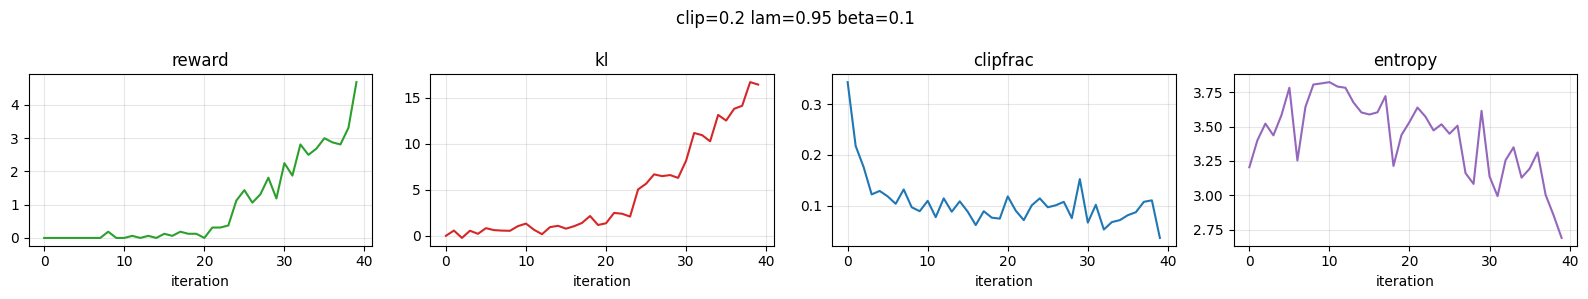


Sample completions after training  (mean reward 4.75):
  [7] I watched the movie last night and was blown away!!! I would recommend this movie! I got the photo awesome!!!
  [7] I watched the movie last night and was so excited!!! So pleased!!! I can't wait to get my fix!
  [4] I watched the movie last night and absolutely enjoy this!!! I LOVE THIS SHIT! I've already ordered the gift
  [1] I watched the movie last night and definitely want to do it directly! I didn't know this movie existed so I
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.387  ent 3.721


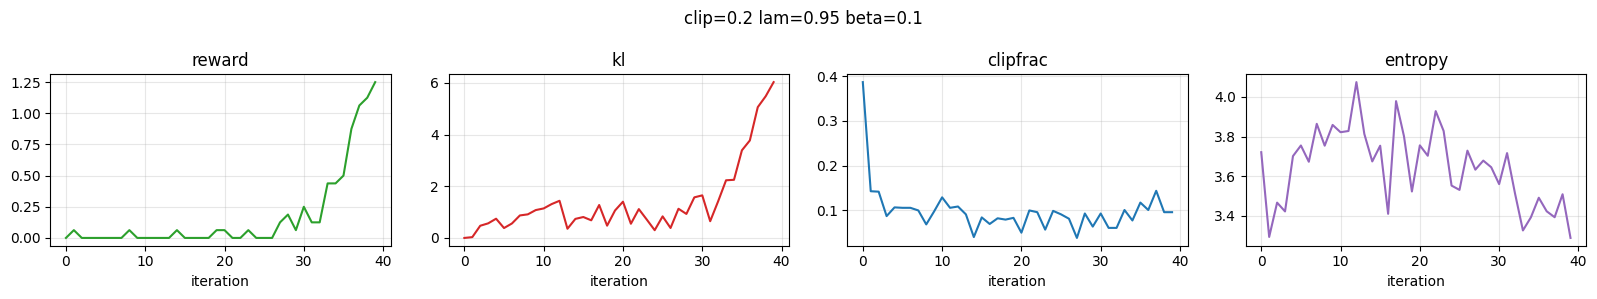


Sample completions after training  (mean reward 2.00):
  [3] I watched the movie last night and I completely forgot! It felt like I just flew! Yea! How much
  [3] I watched the movie last night and could not believe my eyes. The character actor is so mysterious!! Oh hell!
  [1] I watched the movie last night and it struck me as something spectacular! We crested a tall white wall with this
  [1] I watched the movie last night and did not believe everything that I told him! I didn't even remember how much


In [ ]:
run(clip_eps=CLIP_EPS,  gae_lambda=GAE_LAMBDA, kl_coef=STABLE_KL_COEF, lr_exp=LR_EXP, iters=ITERS)

_gae = compute_gae
def compute_gae(rewards, values, gamma, lam):
    _, ret = _gae(rewards, values, gamma, lam)  # ignore the original advantage values
    return ret - ret.mean(), ret
    
run(clip_eps=CLIP_EPS,  gae_lambda=GAE_LAMBDA, kl_coef=STABLE_KL_COEF, lr_exp=LR_EXP, iters=ITERS)
compute_gae = _gae

By killing the critic, we replace per-state advantages $A = G - V_t$ with a batch-mean baseline $A = G - \overline{G}$. A good $V$ tracks returns by state, so you are only surprised by residuals (small, stable $A$); without it, lucky/unlucky rollouts dominate the batch and updates get noisier/slower - that is what GAE bought you. (If $V$ is wrong on the jackpot, it can look as volatile as the mean baseline; the win assumes $V$ is usually in the ballpark.)
